# Skin lesion classification

We segment each image with color-distance thresholding and morphology, then extract 60 shape, color and texture features. A lesion-grouped split protects the holdout from known repeated lesions. Three-fold grouped cross-validation selects between SVM and random forest, with imputation/scaling fitted within each training fold.

The included experiment uses 150 MEL and 150 NV images. It does not represent a full ISIC benchmark. Missing lesion IDs cannot provide patient-level protection. The output is an educational classifier, not a medical diagnosis.

In [1]:
from pathlib import Path
import sys, json, os
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd() if (Path.cwd() / 'cvprojects').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
DATA = Path(os.environ.get('CV_DATA_ROOT', str(ROOT / 'data')))
RUN_PIPELINE = False  # set True after downloading the data


In [2]:
from cvprojects.lesions import build_features, train
if RUN_PIPELINE:
    build_features(DATA / 'isic/manifest.csv', ROOT / 'results/project1/features.csv')
    train(ROOT / 'results/project1/features.csv', ROOT / 'results/project1')
metrics = json.loads((ROOT / 'results/project1/metrics.json').read_text())
display(pd.Series({k: metrics[k] for k in ['sample_count','train_count','test_count','feature_count','selected_model','balanced_accuracy','roc_auc','sensitivity','specificity']}))
display(pd.DataFrame(metrics['cross_validation']).T)

sample_count                   300
train_count                    240
test_count                      60
feature_count                   60
selected_model       random_forest
balanced_accuracy         0.733333
roc_auc                   0.786667
sensitivity               0.633333
specificity               0.833333
dtype: object

,balanced_accuracy,parameters
svm,0.704167,"{'svc__C': 0.1, 'svc__gamma': 'scale'}"
random_forest,0.720833,"{'randomforestclassifier__max_depth': 8, 'rand..."


No known lesion group occurs in both train and test.


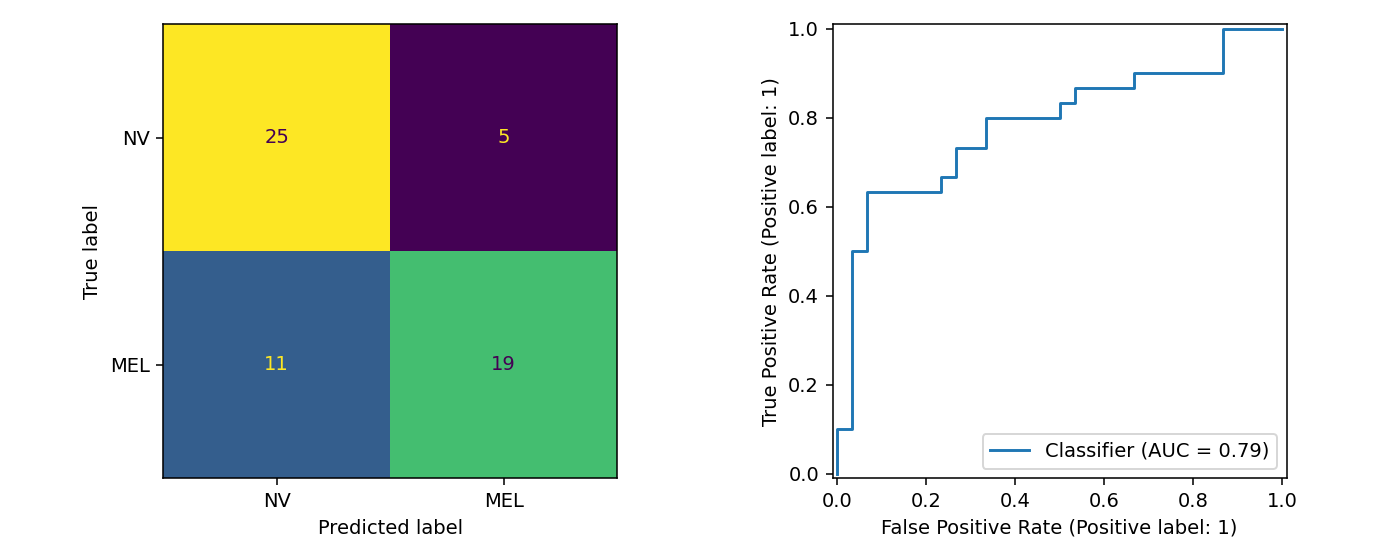

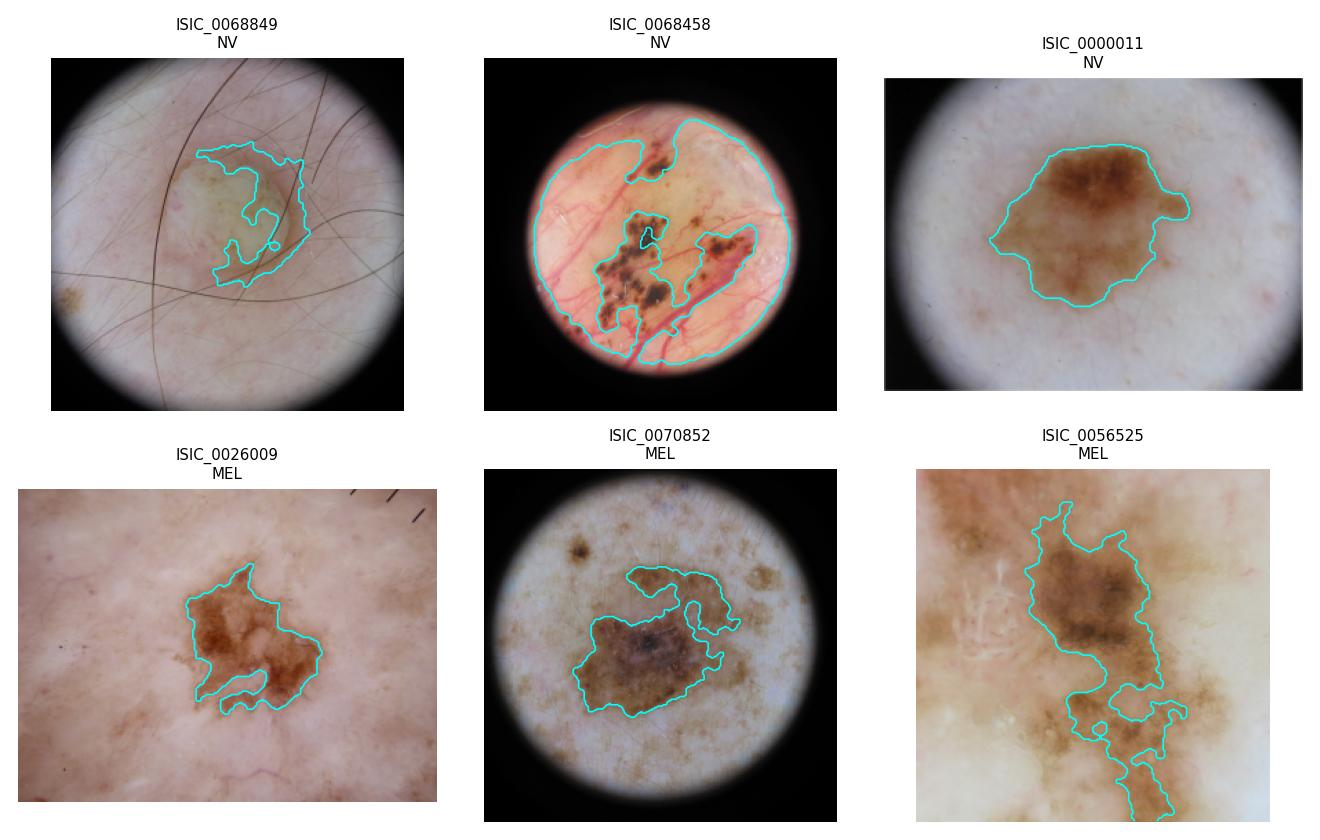

In [3]:
split = pd.read_csv(ROOT / 'results/project1/split_manifest.csv')
assert not set(split.loc[split.split == 'train', 'group']) & set(split.loc[split.split == 'test', 'group'])
print('No known lesion group occurs in both train and test.')
display(Image(filename=str(ROOT / 'results/project1/evaluation.png')))
display(Image(filename=str(ROOT / 'results/project1/segmentation_examples.jpg')))

## Interpretation and reproduction

See `../docs/RESULTS.md` for the observed results and limitations, and `../README.md` for download/run commands. The saved outputs shown above come from the included experiment. Set `RUN_PIPELINE = True` to regenerate them using local datasets.